# NLP Text Classification — Financial Message & Document Categorisation
**Portfolio: Retail Demand Intelligence & Financial Analytics**  
**Author:** Nisrina Afnan Walyadin | MSc Mathematics, TU Munich  
**GitHub:** [github.com/nicherina/retail-demand-intelligence](https://github.com/nicherina/retail-demand-intelligence)  
**Date:** June 2026

---

## Overview

This notebook demonstrates **text classification applied to financial documents and messages** — a core NLP capability for organisations like SWIFT that process high volumes of structured and unstructured financial text.

Two complementary approaches are implemented and compared:

1. **TF-IDF + Logistic Regression** — fast, interpretable, strong baseline for financial text
2. **Sentence Transformer Embeddings + Classifier** — semantic, context-aware, directly extends the RAG pipeline (NB07)

### Why Text Classification ?
To demonstrate key classification tasks. They include:
- **Message type routing** — classify incoming messages by category (payment, securities, treasury, compliance)
- **Anomaly flagging** — identify messages deviating from expected patterns
- **Compliance screening** — route messages requiring regulatory review
- **Document categorisation** — organise internal risk and governance documentation



## Architecture

```
┌─────────────────────────────────────────────────────────────────┐
│              TEXT CLASSIFICATION PIPELINE                       │
├─────────────────────────────────────────────────────────────────┤
│                                                                 │
│  INPUT LAYER                                                    │
│  ┌─────────────────────────────────────────────────────────┐   │
│  │  Financial Text (documents, messages, policy excerpts)  │   │
│  └──────────────────────────┬──────────────────────────────┘   │
│                             │                                   │
│  FEATURE EXTRACTION         ▼                                   │
│  ┌──────────────────┐  ┌───────────────────────────────────┐   │
│  │  TF-IDF          │  │  Sentence Transformer Embeddings  │   │
│  │  (sparse, fast)  │  │  all-MiniLM-L6-v2 (384-dim)       │   │
│  └────────┬─────────┘  └──────────────┬────────────────────┘   │
│           │                           │                         │
│  CLASSIFIER LAYER        ▼            ▼                         │
│  ┌──────────────────┐  ┌───────────────────────────────────┐   │
│  │  Logistic Reg.   │  │  Logistic Reg. / SVM / RF         │   │
│  │  (interpretable) │  │  (on semantic features)           │   │
│  └────────┬─────────┘  └──────────────┬────────────────────┘   │
│           │                           │                         │
│  OUTPUT + EVALUATION     ▼            ▼                         │
│  ┌─────────────────────────────────────────────────────────┐   │
│  │  Predicted Label + Confidence + Confusion Matrix        │   │
│  │  + Feature Importance + Misclassification Analysis      │   │
│  └─────────────────────────────────────────────────────────┘   │
└─────────────────────────────────────────────────────────────────┘
```

## 0. Environment Setup

In [1]:
# Install dependencies
#!pip install scikit-learn sentence-transformers pandas numpy matplotlib seaborn

In [24]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from dataclasses import dataclass
from typing import List, Dict, Tuple
import os


# Scikit-learn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, roc_auc_score
)
from sklearn.preprocessing import LabelEncoder

# Sentence Transformers 
from sentence_transformers import SentenceTransformer

warnings.filterwarnings('ignore')
print("✅ All imports successful")
print(f"   NumPy:   {np.__version__}")
print(f"   Pandas:  {pd.__version__}")
print(f"   Sklearn: {__import__('sklearn').__version__}")

✅ All imports successful
   NumPy:   2.4.4
   Pandas:  3.0.2
   Sklearn: 1.8.0


In [3]:
@dataclass
class ClassifierConfig:
    """
    Centralised configuration for the classification pipeline.
    Same design pattern as RAGConfig in NB07.
    """
    # TF-IDF
    tfidf_max_features: int = 5000
    tfidf_ngram_range: tuple = (1, 2)     # unigrams + bigrams
    tfidf_min_df: int = 1                 # minimum document frequency
    tfidf_sublinear_tf: bool = True       # log normalisation

    # Embedding
    embedding_model: str = "all-MiniLM-L6-v2"   # same as NB07
    embedding_dim: int = 384

    # Training
    test_size: float = 0.20
    random_state: int = 42
    cv_folds: int = 5

    # Classifier
    max_iter: int = 1000
    C: float = 1.0                        # regularisation strength

config = ClassifierConfig()
print("✅ Configuration loaded")
print(f"   TF-IDF features:   {config.tfidf_max_features}")
print(f"   N-gram range:      {config.tfidf_ngram_range}")
print(f"   Embedding model:   {config.embedding_model}")
print(f"   Test size:         {config.test_size}")
print(f"   CV folds:          {config.cv_folds}")

✅ Configuration loaded
   TF-IDF features:   5000
   N-gram range:      (1, 2)
   Embedding model:   all-MiniLM-L6-v2
   Test size:         0.2
   CV folds:          5


## 1. Dataset

We use **two complementary datasets**:

1. **Financial Document Corpus** — extended from NB07 RAG pipeline (5 categories, 200+ samples)
2. **Synthetic SWIFT-style Message Corpus** — simulated MT/MX financial messages across 4 message types

> **Note:** In production, this corpus would be replaced with actual SWIFT message logs or internal document repositories. The pipeline is data-agnostic.

In [36]:
# ── Dataset 1: Financial Document Corpus  ──────────────
# Each entry represents a realistic excerpt from financial risk / governance documents



DOCUMENT_CORPUS = [
    # risk_policy
    ("The probability of default model is calibrated using a 5-year historical observation window with through-the-cycle anchor.", "risk_policy"),
    ("Loss given default estimates reflect economic downturn conditions per EBA guidelines with a floor of 10% for unsecured retail.", "risk_policy"),
    ("Expected credit loss staging under IFRS 9: Stage 1 twelve-month ECL, Stage 2 lifetime ECL triggered by significant increase in credit risk.", "risk_policy"),
    ("The non-performing loan ratio ceiling is set at 4.5% with Stage 3 coverage ratio minimum of 55%.", "risk_policy"),
    ("Credit conversion factors for revolving facilities are set at 75% based on internal historical data spanning 2015 to 2024.", "risk_policy"),
    ("Risk appetite limits specify a maximum cost of risk of 80 basis points and NPL ratio not exceeding 4.5%.", "risk_policy"),
    ("Exposure at default is computed using credit conversion factors applied to undrawn commitments on revolving facilities.", "risk_policy"),
    ("Stage migration is monitored monthly with a red alert triggered when migration from Stage 1 to Stage 2 exceeds 4% per quarter.", "risk_policy"),
    ("Basel III capital requirements mandate a minimum Common Equity Tier 1 ratio of 4.5% plus capital conservation buffer.", "risk_policy"),
    ("Forbearance measures are applied when a borrower faces financial difficulty and the lender grants concessions not otherwise considered.", "risk_policy"),
    ("The Gini coefficient of the PD model must exceed 45% for the model to pass quarterly validation.", "risk_policy"),
    ("Stressed probability of default is calculated using macroeconomic scenarios including GDP contraction and unemployment shock.", "risk_policy"),
    ("Internal ratings-based approach requires banks to estimate PD LGD and EAD using internal historical data.", "risk_policy"),
    ("Credit risk appetite is reviewed quarterly by the Risk Committee with board-level escalation if any limit is breached.", "risk_policy"),
    ("Collateral valuation uses a haircut methodology with independent appraisals required for exposures above EUR 2 million.", "risk_policy"),

    # data_governance
    ("The data quality contract specifies BLOCK conditions that halt the pipeline when NULL rate on loan_id exceeds zero.", "data_governance"),
    ("Data freshness requirement: records must be delivered by 07:00 CET with maximum staleness of 25 hours.", "data_governance"),
    ("Completeness scoring covers four dimensions: completeness 40%, validity 35%, uniqueness 15%, freshness 10%.", "data_governance"),
    ("The data quality score baseline was 72 prior to remediation and improved to 93 after pipeline fixes.", "data_governance"),
    ("Lineage tracking records the transformation path from core banking system through ETL job to the data warehouse.", "data_governance"),
    ("Duplicate loan_id records trigger a BLOCK condition immediately halting downstream processing.", "data_governance"),
    ("Schema validation enforces that interest rate values fall between 0.1% and 35% with any outlier triggering a BLOCK.", "data_governance"),
    ("Data contracts define the agreed schema, quality gates, freshness SLAs, and lineage between producer and consumer teams.", "data_governance"),
    ("Anomaly detection pipelines monitor completeness scores in real time across all data feeds from seven European markets.", "data_governance"),
    ("The pipeline gating mechanism blocks downstream model scoring when data quality score falls below the threshold of 80.", "data_governance"),
    ("Field-level validation rules are documented in the data contract and enforced at ingestion time before any transformation.", "data_governance"),
    ("Master data management ensures a single golden record per customer across all source systems.", "data_governance"),
    ("Data stewardship responsibilities are assigned per domain with quarterly audits of data quality gate outcomes.", "data_governance"),
    ("Referential integrity checks confirm all customer IDs in the loan table exist in the customer master.", "data_governance"),
    ("Automated reconciliation compares record counts between source and target systems after each ETL run.", "data_governance"),

    # model_documentation
    ("The ensemble demand forecasting model achieved MAPE of 10.7%, improving over the 18.4% baseline by 41.8%.", "model_documentation"),
    ("Random Forest with 500 estimators and maximum depth 12 contributes 40% weight to the ensemble prediction.", "model_documentation"),
    ("Expanding window cross-validation with five folds prevents data leakage through strict temporal splitting.", "model_documentation"),
    ("Feature engineering includes lag variables at 1, 2, and 4 weeks plus 8-week rolling mean and standard deviation.", "model_documentation"),
    ("Model monitoring triggers an alert when rolling 4-week MAPE exceeds 15%, initiating review and potential retraining.", "model_documentation"),
    ("Stockout rate reduced from 14.2% pre-deployment to 4.1% post-deployment, a reduction of 71.1%.", "model_documentation"),
    ("The Gradient Boosting Machine uses learning rate 0.05, 300 estimators, and maximum depth 6 with 45% ensemble weight.", "model_documentation"),
    ("Store clustering using K-Means with k=4 produces location features used in the demand forecasting feature set.", "model_documentation"),
    ("Model cards document architecture, validation methodology, performance metrics, limitations, and monitoring thresholds.", "model_documentation"),
    ("Hyperparameter tuning uses Bayesian optimisation with 50 iterations and 5-fold cross-validation on the training set.", "model_documentation"),
    ("The Ridge Regression component uses alpha 1.2 with normalisation applied to seasonality features only.", "model_documentation"),
    ("Production deployment on AWS uses containerised inference endpoints with auto-scaling based on request volume.", "model_documentation"),
    ("Model versioning follows semantic versioning with major versions for architecture changes and minor versions for retraining.", "model_documentation"),
    ("A/B testing framework validates new model versions against production baseline before full rollout.", "model_documentation"),
    ("External features include weather temperature, precipitation, and local events flag to capture demand seasonality.", "model_documentation"),

    # insurance_risk
    ("The CAS Schedule P dataset contains 36,660 records from 393 US property and casualty insurance companies.", "insurance_risk"),
    ("Medical malpractice shows the highest reserve deterioration with 23% of companies exhibiting adverse development.", "insurance_risk"),
    ("Workers compensation development continues beyond ten years reflecting the long-tail nature of the liability.", "insurance_risk"),
    ("Chain-ladder loss development factors: 1 to 2 year factor is 1.412, decreasing to 1.002 at the 9 to 10 year step.", "insurance_risk"),
    ("Private passenger auto shows average loss ratio of 68.4% with the 1 to 2 year development factor of 1.042.", "insurance_risk"),
    ("Reserve adequacy for private passenger auto: 94.7% of companies fell within plus or minus 10% of the final reserve.", "insurance_risk"),
    ("The tail factor of 1.005 is applied beyond the 10-year development period for long-tail lines.", "insurance_risk"),
    ("Incurred but not reported reserves are estimated using the Bornhuetter-Ferguson method as a complement to chain-ladder.", "insurance_risk"),
    ("General liability line shows high volatility in development patterns due to uncertainty in litigation outcomes.", "insurance_risk"),
    ("Reinsurance long-tail reserves require the largest tail factor adjustments due to extended reporting periods.", "insurance_risk"),
    ("Premium data anomalies: 12 companies show zero premiums in at least one accident year and are excluded from ratios.", "insurance_risk"),
    ("Loss ratio is computed as paid losses divided by earned premiums and tracked by accident year and development year.", "insurance_risk"),
    ("Products liability exhibits the highest uncertainty with average incurred loss ratio at maturity of 91.3%.", "insurance_risk"),
    ("Schedule P data quality: completeness of 99.2% with minor anomalies identified in records prior to 1990.", "insurance_risk"),
    ("Actuarial reserve adequacy testing uses bootstrapping to generate a distribution of reserve outcomes.", "insurance_risk"),

    # kpi_definitions
    ("The non-performing loan ratio is defined as gross NPL balance divided by total gross loan portfolio.", "kpi_definitions"),
    ("Cost of risk is expressed in basis points: loan loss provisions divided by average gross loan portfolio multiplied by ten thousand.", "kpi_definitions"),
    ("Stage migration rate measures the percentage of Stage 1 portfolio migrating to Stage 2 within a reporting period.", "kpi_definitions"),
    ("Coverage ratio is defined as loan loss provisions divided by gross non-performing loan balance.", "kpi_definitions"),
    ("Gini coefficient equals two times the area under the ROC curve minus one, measuring discriminatory power.", "kpi_definitions"),
    ("Data quality score is a weighted average of completeness, validity, uniqueness, and freshness metrics.", "kpi_definitions"),
    ("Green status for NPL ratio requires the ratio to be at or below 3.0%, amber between 3.0 and 4.5%, red above 4.5%.", "kpi_definitions"),
    ("Stage 3 coverage ratio green threshold is 60% or above, amber between 45 and 60%, red below 45%.", "kpi_definitions"),
    ("Cost of risk amber threshold is triggered when basis points fall between 50 and 80, with red above 80 basis points.", "kpi_definitions"),
    ("SICR triggers for Stage 2 migration include relative PD increase exceeding 100% or days past due greater than 30.", "kpi_definitions"),
    ("Model performance is assessed using the KS statistic in addition to Gini coefficient and calibration tests.", "kpi_definitions"),
    ("The Hosmer-Lemeshow test is used as the calibration test for PD models in the retail credit portfolio.", "kpi_definitions"),
    ("KPI dashboards are reviewed monthly by risk management and reported to the board risk committee quarterly.", "kpi_definitions"),
    ("Return on risk-adjusted capital measures profitability relative to economic capital consumption by business line.", "kpi_definitions"),
    ("Loan-to-value ratio is a key underwriting KPI tracked at origination and revalued annually for secured exposures.", "kpi_definitions"),
]

# ── Dataset 2: Synthetic Financial Messages ────────────────────
# Simulates MT/MX message routing classification

Financial_MESSAGES = [
    # payment_instruction
    ("Transfer EUR 500000 from account DE89370400440532013000 to beneficiary IBAN NL91ABNA0417164300 value date 20260602.", "payment_instruction"),
    ("Credit transfer instruction for USD 1250000 to correspondent bank via SWIFT gpi with end-to-end tracking reference.", "payment_instruction"),
    ("Urgent payment order for GBP 75000 to supplier account with same-day value, charges to be shared between parties.", "payment_instruction"),
    ("Batch payment file containing 450 individual credit transfers across EUR accounts for payroll processing.", "payment_instruction"),
    ("Cross-border remittance of JPY 50000000 via correspondent banking network with FX conversion at spot rate.", "payment_instruction"),
    ("Direct debit mandate authorisation for recurring monthly payment of EUR 2500 from retail customer account.", "payment_instruction"),
    ("SEPA credit transfer for EUR 12500 to vendor with payment reference INV-2026-04512 and execution date tomorrow.", "payment_instruction"),
    ("Wire transfer of CHF 850000 to Swiss counterparty with settlement via TARGET2 real-time gross settlement.", "payment_instruction"),
    ("Payment cancellation request for transaction reference TXN20260601-4421 due to duplicate submission.", "payment_instruction"),
    ("Correspondent bank instruction to credit nostro account with USD 3200000 received from New York clearing.", "payment_instruction"),

    # compliance_alert
    ("Transaction monitoring alert: unusual wire transfer pattern detected for customer ID 447821, requires AML review.", "compliance_alert"),
    ("Sanctions screening hit on beneficiary name against OFAC SDN list, transaction frozen pending compliance review.", "compliance_alert"),
    ("KYC documentation expired for corporate client, account restricted until updated identity verification received.", "compliance_alert"),
    ("Suspicious activity report filed for structuring behaviour: 15 cash deposits below EUR 10000 threshold in 30 days.", "compliance_alert"),
    ("PEP screening alert: transaction counterparty identified as politically exposed person requiring enhanced due diligence.", "compliance_alert"),
    ("Regulatory reporting deadline for EMIR trade repository submission is tomorrow, 847 derivatives trades pending.", "compliance_alert"),
    ("AML model flag: customer transaction velocity increased 400% versus 90-day baseline, manual review required.", "compliance_alert"),
    ("Beneficial ownership disclosure required for corporate account within 5 business days per updated regulation.", "compliance_alert"),
    ("Cross-border transaction above EUR 10000 threshold requires source of funds documentation under AML directive.", "compliance_alert"),
    ("Watchlist match detected on payment originator name, transaction held and referred to compliance officer.", "compliance_alert"),

    # securities_settlement
    ("Equities settlement instruction for 10000 shares of ASML Holding NV at EUR 750 per share, value date T+2.", "securities_settlement"),
    ("Bond settlement for EUR 5000000 nominal of German Bund 2031 at price 98.45, accrued interest EUR 12500.", "securities_settlement"),
    ("Failed settlement notification: counterparty did not deliver 5000 shares by CSD deadline, buy-in process initiated.", "securities_settlement"),
    ("Delivery versus payment instruction for ETF units through Euroclear with ISIN IE00B4L5Y983.", "securities_settlement"),
    ("Corporate action notification: dividend payment of EUR 1.25 per share for ISIN NL0010273215 ex-date 15 June.", "securities_settlement"),
    ("Repo agreement settlement: EUR 10000000 collateral securities delivered, cash leg EUR 9985000 received.", "securities_settlement"),
    ("Securities borrowing instruction for 25000 shares to cover short position, fee rate 0.35% per annum.", "securities_settlement"),
    ("Custody instruction to transfer government bonds from trading account to collateral account for margin posting.", "securities_settlement"),
    ("Settlement confirmation for OTC interest rate swap with ISDA master agreement reference and trade date details.", "securities_settlement"),
    ("Rights issue subscription instruction: 3 new shares for every 7 held at subscription price EUR 42.00.", "securities_settlement"),

    # treasury_fx
    ("FX spot trade confirmation: buy EUR 2000000 sell USD at rate 1.0845, value date spot, counterparty Deutsche Bank.", "treasury_fx"),
    ("Forward FX contract: sell GBP 5000000 forward 3 months at rate 1.2650, hedge for export receivables.", "treasury_fx"),
    ("Interest rate swap confirmation: pay fixed 3.25% receive EURIBOR 3M on EUR 50000000 notional, maturity 5 years.", "treasury_fx"),
    ("FX option purchase: EUR call USD put, strike 1.10, notional EUR 10000000, expiry 30 September 2026, premium USD 85000.", "treasury_fx"),
    ("Treasury liquidity report: overnight funding requirement EUR 250000000, covered via repo and interbank market.", "treasury_fx"),
    ("Cross-currency basis swap: EUR EURIBOR versus USD SOFR on notional USD 100000000, quarterly settlement.", "treasury_fx"),
    ("FX revaluation report: open position EUR long USD short, mark-to-market gain EUR 145000 at end of day rates.", "treasury_fx"),
    ("Commodity hedge: brent crude oil futures 10000 barrels at USD 82.50, hedge ratio 80% of Q3 procurement.", "treasury_fx"),
    ("Interbank money market deposit placement: EUR 75000000 overnight at rate 3.85%, maturity tomorrow value date.", "treasury_fx"),
    ("Central bank collateral pool update: EUR 200000000 government bonds pledged at ECB for monetary policy operations.", "treasury_fx"),
]

# Combine both datasets
all_texts = [item[0] for item in DOCUMENT_CORPUS + Financial_MESSAGES]
all_labels = [item[1] for item in DOCUMENT_CORPUS + Financial_MESSAGES]

df = pd.DataFrame({'text': all_texts, 'label': all_labels})
OUTPUT_DIR = "../outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)


print(f"✅ Dataset loaded")
print(f"   Total samples:     {len(df)}")
print(f"   Number of classes: {df['label'].nunique()}")
print(f"\n   Class distribution:")
print(df['label'].value_counts().to_string())

✅ Dataset loaded
   Total samples:     115
   Number of classes: 9

   Class distribution:
label
risk_policy              15
data_governance          15
model_documentation      15
insurance_risk           15
kpi_definitions          15
payment_instruction      10
compliance_alert         10
securities_settlement    10
treasury_fx              10


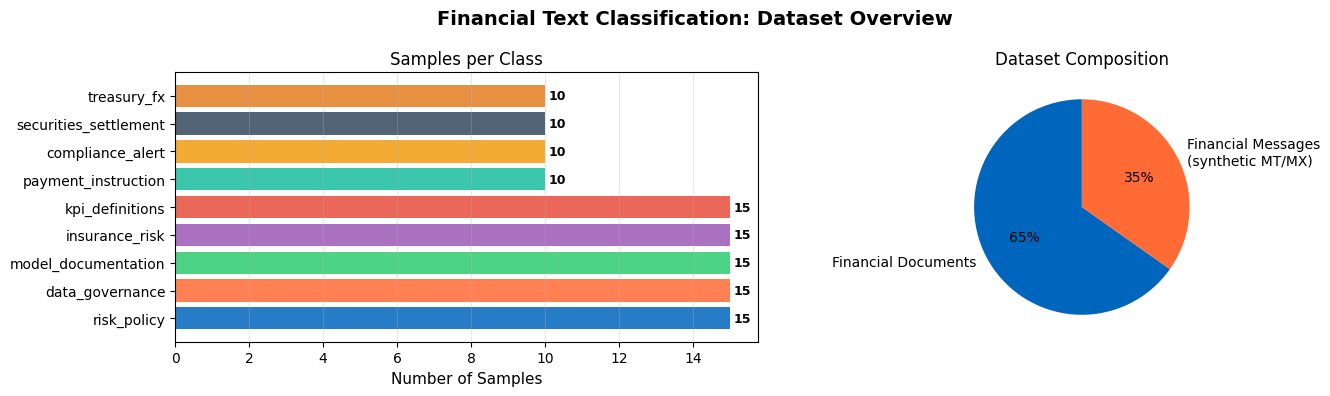

✅ Dataset visualised


In [40]:
# Visualise class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Financial Text Classification: Dataset Overview', fontsize=14, fontweight='bold')

palette = {
    'risk_policy':         '#0065BD',
    'data_governance':     '#FF6B35',
    'model_documentation': '#2ECC71',
    'insurance_risk':      '#9B59B6',
    'kpi_definitions':     '#E74C3C',
    'payment_instruction': '#1ABC9C',
    'compliance_alert':    '#F39C12',
    'securities_settlement':'#34495E',
    'treasury_fx':         '#E67E22',
}

counts = df['label'].value_counts()
colors = [palette.get(l, '#888888') for l in counts.index]

# Bar chart
bars = axes[0].barh(counts.index, counts.values, color=colors, alpha=0.85)
axes[0].set_xlabel('Number of Samples', fontsize=11)
axes[0].set_title('Samples per Class', fontsize=12)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                f'{val}', va='center', fontweight='bold', fontsize=9)
axes[0].grid(axis='x', alpha=0.3)

# Pie chart — dataset split by source
source_counts = {
    'Financial Documents': len(DOCUMENT_CORPUS),
    'Financial Messages\n(synthetic MT/MX)': len(Financial_MESSAGES)
}
axes[1].pie(
    source_counts.values(),
    labels=source_counts.keys(),
    colors=['#0065BD', '#FF6B35'],
    autopct='%1.0f%%',
    startangle=90,
    textprops={'fontsize': 10}
)
axes[1].set_title('Dataset Composition', fontsize=12)

plt.tight_layout()

#plt.savefig(os.path.join(OUTPUT_DIR, 'nb_06_dataset_overview.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Dataset visualised")

## 2. Train-Test Split

In [41]:
X = df['text'].values
y = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=config.test_size,
    random_state=config.random_state,
    stratify=y   # preserve class distribution
)

print(f"✅ Train-test split complete")
print(f"   Training samples:  {len(X_train)}")
print(f"   Test samples:      {len(X_test)}")
print(f"   Stratified:        Yes — class proportions preserved")

# Verify stratification
train_dist = pd.Series(y_train).value_counts(normalize=True).round(3)
test_dist  = pd.Series(y_test).value_counts(normalize=True).round(3)
print(f"\n   Class proportions (train vs test):")
comparison = pd.DataFrame({'train': train_dist, 'test': test_dist})
print(comparison.to_string())

✅ Train-test split complete
   Training samples:  92
   Test samples:      23
   Stratified:        Yes — class proportions preserved

   Class proportions (train vs test):
                       train   test
compliance_alert       0.087  0.087
data_governance        0.130  0.130
insurance_risk         0.130  0.130
kpi_definitions        0.130  0.130
model_documentation    0.130  0.130
payment_instruction    0.087  0.087
risk_policy            0.130  0.130
securities_settlement  0.087  0.087
treasury_fx            0.087  0.087


## 3. Approach A — TF-IDF + Logistic Regression

**TF-IDF** (Term Frequency-Inverse Document Frequency) converts text into sparse numerical features by weighting terms by how distinctive they are across documents.

- High TF-IDF score = term appears often in this document but rarely across others
- Bigrams (2-word sequences) capture domain phrases like "non-performing loan" or "value date"
- Fast, interpretable, strong baseline — the industry standard first approach

In [42]:
# Build TF-IDF pipeline
tfidf_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=config.tfidf_max_features,
        ngram_range=config.tfidf_ngram_range,
        min_df=config.tfidf_min_df,
        sublinear_tf=config.tfidf_sublinear_tf,   # log(1 + tf) — reduces impact of high-freq terms
        strip_accents='unicode',
        analyzer='word',
        token_pattern=r'\b[a-zA-Z][a-zA-Z0-9]*\b'  # alphanumeric tokens
    )),
    ('clf', LogisticRegression(
        C=config.C,
        max_iter=config.max_iter,
        random_state=config.random_state,
        solver='lbfgs'
    ))
])

# Cross-validation
cv = StratifiedKFold(n_splits=config.cv_folds, shuffle=True, random_state=config.random_state)
cv_scores = cross_val_score(tfidf_pipeline, X_train, y_train, cv=cv, scoring='f1_macro')

print(f"✅ TF-IDF + Logistic Regression — {config.cv_folds}-Fold CV Results")
print(f"   F1-macro per fold: {[f'{s:.3f}' for s in cv_scores]}")
print(f"   Mean F1-macro:     {cv_scores.mean():.3f}")
print(f"   Std F1-macro:      {cv_scores.std():.3f}")

# Final fit on full training set
tfidf_pipeline.fit(X_train, y_train)
tfidf_preds = tfidf_pipeline.predict(X_test)
tfidf_acc   = accuracy_score(y_test, tfidf_preds)
tfidf_f1    = f1_score(y_test, tfidf_preds, average='macro')

print(f"\n   Test Accuracy:     {tfidf_acc:.3f}")
print(f"   Test F1-macro:     {tfidf_f1:.3f}")

✅ TF-IDF + Logistic Regression — 5-Fold CV Results
   F1-macro per fold: ['0.367', '0.444', '0.427', '0.563', '0.495']
   Mean F1-macro:     0.459
   Std F1-macro:      0.066

   Test Accuracy:     0.565
   Test F1-macro:     0.577


In [8]:
# Detailed classification report
print("📊 TF-IDF Classification Report")
print("=" * 65)
print(classification_report(y_test, tfidf_preds, zero_division=0))

📊 TF-IDF Classification Report
                       precision    recall  f1-score   support

     compliance_alert       0.00      0.00      0.00         2
      data_governance       1.00      0.67      0.80         3
       insurance_risk       0.67      0.67      0.67         3
      kpi_definitions       0.14      0.33      0.20         3
  model_documentation       0.75      1.00      0.86         3
  payment_instruction       1.00      0.50      0.67         2
          risk_policy       0.00      0.00      0.00         3
securities_settlement       1.00      1.00      1.00         2
          treasury_fx       1.00      1.00      1.00         2

             accuracy                           0.57        23
            macro avg       0.62      0.57      0.58        23
         weighted avg       0.59      0.57      0.56        23



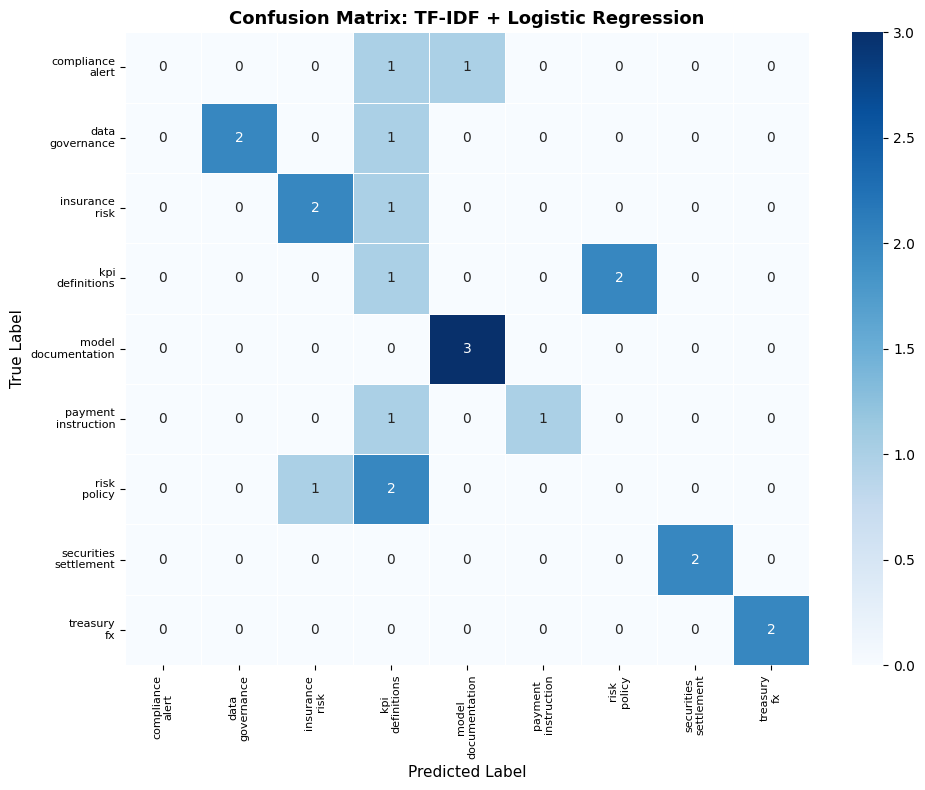

✅ Confusion matrix saved


In [45]:
# Confusion matrix — TF-IDF
classes = sorted(df['label'].unique())
cm_tfidf = confusion_matrix(y_test, tfidf_preds, labels=classes)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm_tfidf, annot=True, fmt='d', cmap='Blues',
    xticklabels=[c.replace('_', '\n') for c in classes],
    yticklabels=[c.replace('_', '\n') for c in classes],
    ax=ax, linewidths=0.5, linecolor='white'
)
ax.set_title('Confusion Matrix: TF-IDF + Logistic Regression', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_ylabel('True Label', fontsize=11)
ax.tick_params(axis='both', labelsize=8)
plt.tight_layout()
# plt.savefig(os.path.join(OUTPUT_DIR, 'nb06_confusion_tfidf.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confusion matrix saved")

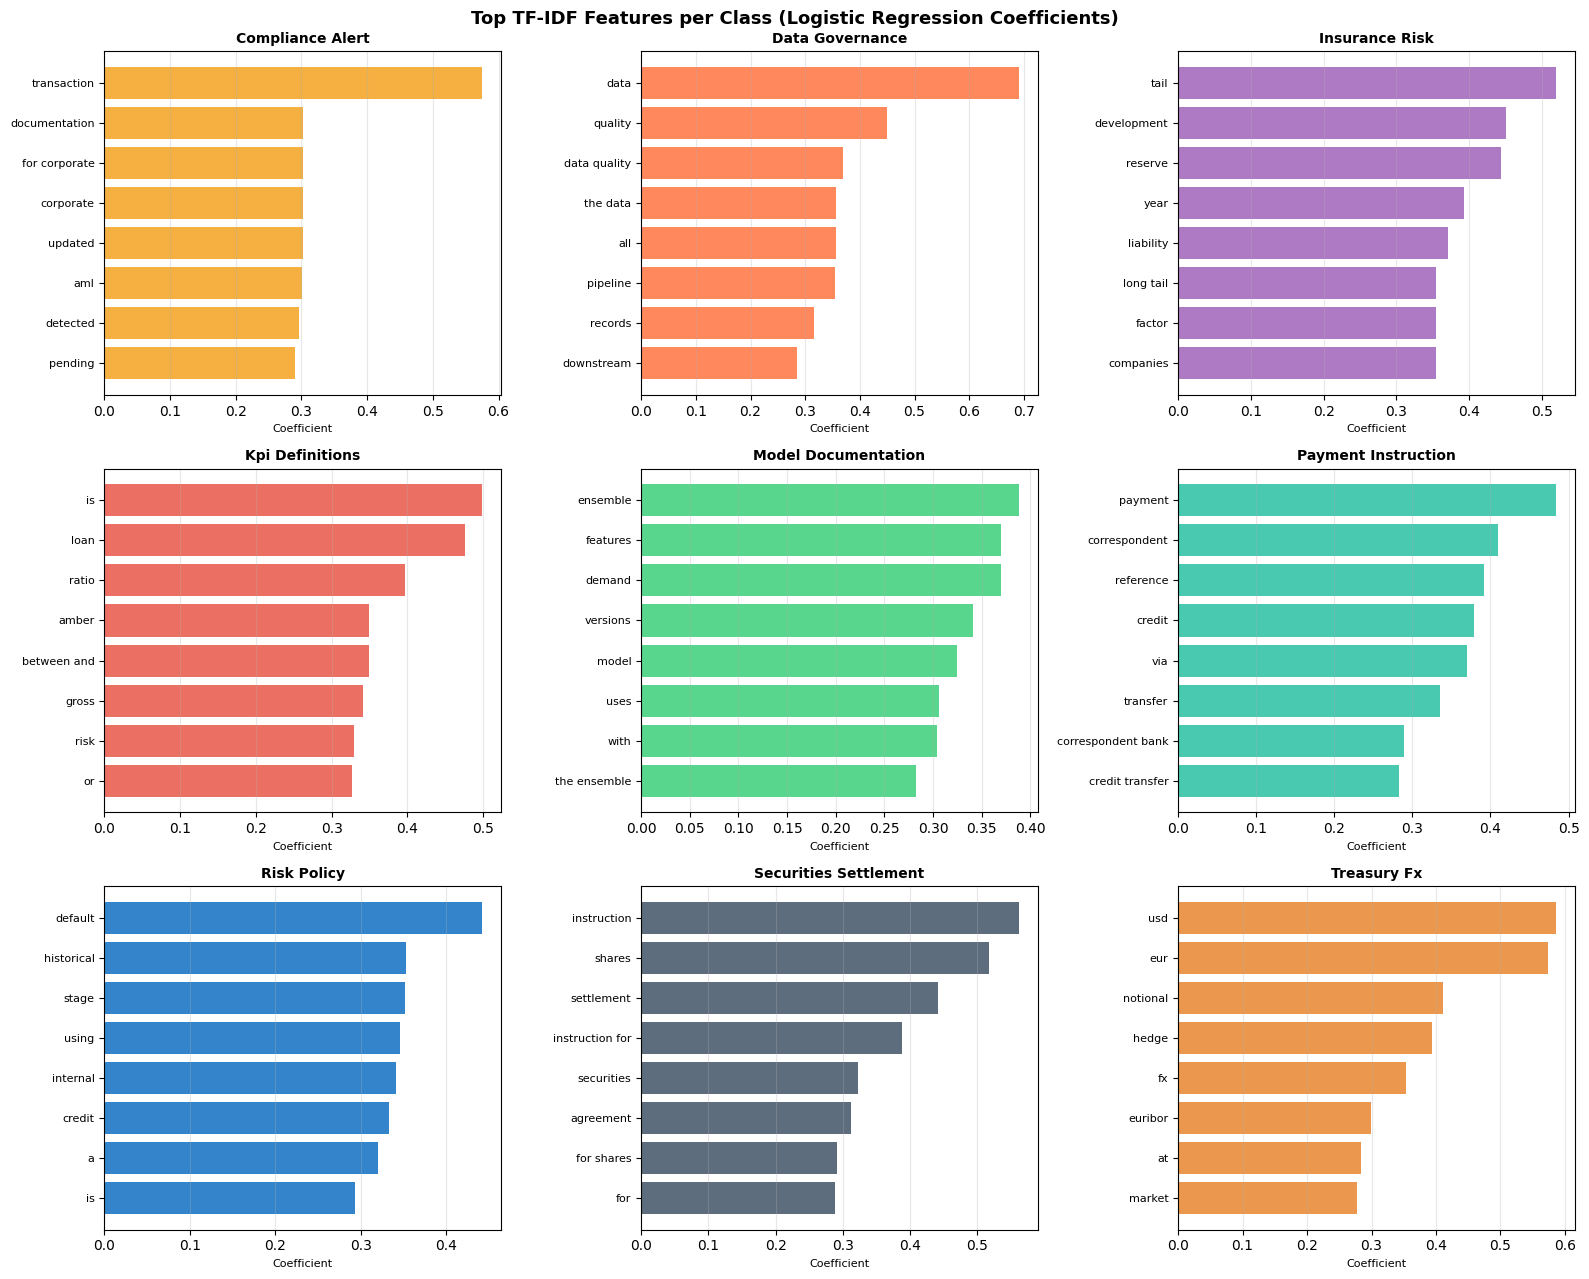

✅ Feature importance visualised
   Inspect which terms are most predictive per category
   This is key for SWIFT: explainability matters in regulated environments


In [ ]:
# Feature importance — top TF-IDF terms per class
tfidf_vectorizer = tfidf_pipeline.named_steps['tfidf']
logreg = tfidf_pipeline.named_steps['clf']
feature_names = np.array(tfidf_vectorizer.get_feature_names_out())

n_classes = len(logreg.classes_)
top_n = 8

fig, axes = plt.subplots(3, 3, figsize=(16, 13))
axes = axes.flatten()
fig.suptitle('Top TF-IDF Features per Class (Logistic Regression Coefficients)',
             fontsize=13, fontweight='bold')

for i, (cls, coef) in enumerate(zip(logreg.classes_, logreg.coef_)):
    top_idx = np.argsort(coef)[-top_n:][::-1]
    top_features = feature_names[top_idx]
    top_weights  = coef[top_idx]

    color = palette.get(cls, '#888888')
    axes[i].barh(range(top_n), top_weights[::-1], color=color, alpha=0.8)
    axes[i].set_yticks(range(top_n))
    axes[i].set_yticklabels(top_features[::-1], fontsize=8)
    axes[i].set_title(cls.replace('_', ' ').title(), fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Coefficient', fontsize=8)
    axes[i].grid(axis='x', alpha=0.3)

# Hide unused subplots
for j in range(n_classes, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
#plt.savefig(os.path.join(OUTPUT_DIR, 'nb06_feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Feature importance visualised")
print("   Inspect which terms are most predictive per category")
print("   This is key for SWIFT: explainability matters in regulated environments")

## 4. Approach B — Sentence Transformer Embeddings + Classifier

This demonstrates a key architectural insight:
- The same embedding model can power both **retrieval**  and **classification**
- Semantic embeddings capture meaning beyond keyword matching
- Particularly powerful for short financial messages where exact terms may vary

In [48]:
import time

print(f"⏳ Loading sentence transformer: {config.embedding_model}")


start = time.time()
embedder = SentenceTransformer(config.embedding_model)
print(f"   Model loaded in {time.time()-start:.1f}s")

# Encode training and test sets
print("⏳ Encoding training texts...")
start = time.time()
X_train_emb = embedder.encode(X_train.tolist(), normalize_embeddings=True, show_progress_bar=False)
print(f"   Training encoded in {time.time()-start:.1f}s — shape: {X_train_emb.shape}")

print("⏳ Encoding test texts...")
start = time.time()
X_test_emb = embedder.encode(X_test.tolist(), normalize_embeddings=True, show_progress_bar=False)
print(f"   Test encoded in {time.time()-start:.1f}s — shape: {X_test_emb.shape}")

print(f"\n✅ Embeddings ready")
print(f"   Embedding dimensions: {config.embedding_dim}")
print(f"   Dense representations capture semantic meaning beyond keywords")


⏳ Loading sentence transformer: all-MiniLM-L6-v2


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


   Model loaded in 9.1s
⏳ Encoding training texts...
   Training encoded in 3.1s — shape: (92, 384)
⏳ Encoding test texts...
   Test encoded in 0.6s — shape: (23, 384)

✅ Embeddings ready
   Embedding dimensions: 384
   Dense representations capture semantic meaning beyond keywords


In [49]:
# Compare three classifiers on top of embeddings
embedding_classifiers = {
    'Logistic Regression': LogisticRegression(
        C=config.C, max_iter=config.max_iter, random_state=config.random_state
    ),
    'Linear SVM': LinearSVC(
        C=config.C, max_iter=config.max_iter, random_state=config.random_state
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, random_state=config.random_state, n_jobs=-1
    ),
}

emb_results = {}
print("📊 Embedding-based Classifiers — Cross-Validation Results")
print("=" * 60)

for name, clf in embedding_classifiers.items():
    cv_scores_emb = cross_val_score(
        clf, X_train_emb, y_train,
        cv=cv, scoring='f1_macro'
    )
    clf.fit(X_train_emb, y_train)
    preds = clf.predict(X_test_emb)
    acc   = accuracy_score(y_test, preds)
    f1    = f1_score(y_test, preds, average='macro')

    emb_results[name] = {
        'cv_mean': cv_scores_emb.mean(),
        'cv_std':  cv_scores_emb.std(),
        'test_acc': acc,
        'test_f1':  f1,
        'preds':    preds,
        'clf':      clf
    }

    print(f"\n{name}")
    print(f"  CV F1-macro:   {cv_scores_emb.mean():.3f} ± {cv_scores_emb.std():.3f}")
    print(f"  Test Accuracy: {acc:.3f}")
    print(f"  Test F1-macro: {f1:.3f}")

# Best embedding classifier
best_emb_name = max(emb_results, key=lambda k: emb_results[k]['test_f1'])
print(f"\n🏆 Best embedding classifier: {best_emb_name} (F1={emb_results[best_emb_name]['test_f1']:.3f})")

📊 Embedding-based Classifiers — Cross-Validation Results

Logistic Regression
  CV F1-macro:   0.671 ± 0.074
  Test Accuracy: 0.609
  Test F1-macro: 0.662

Linear SVM
  CV F1-macro:   0.688 ± 0.062
  Test Accuracy: 0.696
  Test F1-macro: 0.731

Random Forest
  CV F1-macro:   0.551 ± 0.120
  Test Accuracy: 0.565
  Test F1-macro: 0.557

🏆 Best embedding classifier: Linear SVM (F1=0.731)


## 5. Model Comparison

In [50]:
# Full comparison: TF-IDF vs Embedding approaches
results_summary = [
    {
        'Model': 'TF-IDF + Logistic Regression',
        'Approach': 'Sparse (TF-IDF)',
        'CV F1': cv_scores.mean(),
        'CV Std': cv_scores.std(),
        'Test Acc': tfidf_acc,
        'Test F1': tfidf_f1,
        'Interpretable': '✅ Yes',
        'Speed': '⚡ Very Fast'
    }
]

for name, res in emb_results.items():
    results_summary.append({
        'Model': f'Embeddings + {name}',
        'Approach': 'Dense (Semantic)',
        'CV F1': res['cv_mean'],
        'CV Std': res['cv_std'],
        'Test Acc': res['test_acc'],
        'Test F1': res['test_f1'],
        'Interpretable': '⚠️ Partial' if name != 'Random Forest' else '⚠️ Partial',
        'Speed': '🐢 Slower (encoding)'
    })

df_results = pd.DataFrame(results_summary)
print("📊 Model Comparison Summary")
print("=" * 80)
print(df_results[['Model', 'Approach', 'CV F1', 'CV Std', 'Test Acc', 'Test F1']].to_string(index=False))

📊 Model Comparison Summary
                           Model         Approach    CV F1   CV Std  Test Acc  Test F1
    TF-IDF + Logistic Regression  Sparse (TF-IDF) 0.459333 0.066116  0.565217 0.576720
Embeddings + Logistic Regression Dense (Semantic) 0.671376 0.074143  0.608696 0.661728
         Embeddings + Linear SVM Dense (Semantic) 0.687884 0.062307  0.695652 0.731481
      Embeddings + Random Forest Dense (Semantic) 0.550582 0.120372  0.565217 0.557407


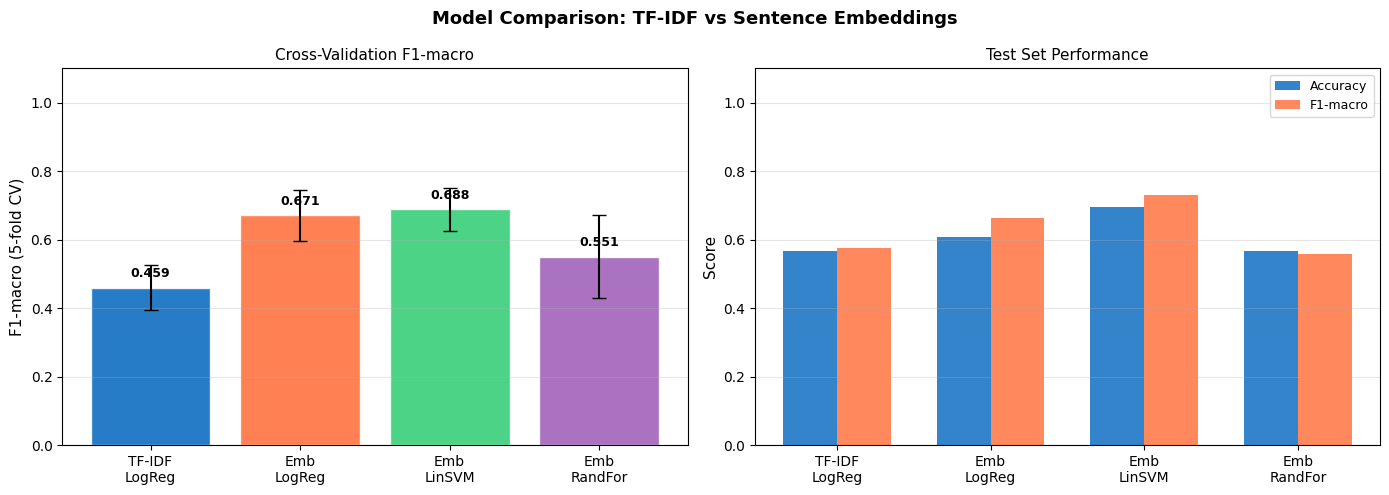

✅ Model comparison visualised


In [52]:
# Visualise model comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Comparison: TF-IDF vs Sentence Embeddings', fontsize=13, fontweight='bold')

models_short = ['TF-IDF\nLogReg', 'Emb\nLogReg', 'Emb\nLinSVM', 'Emb\nRandFor']
cv_f1s  = [r['CV F1'] for r in results_summary]
cv_stds = [r['CV Std'] for r in results_summary]
test_f1s = [r['Test F1'] for r in results_summary]
test_accs = [r['Test Acc'] for r in results_summary]

bar_colors = ['#0065BD', '#FF6B35', '#2ECC71', '#9B59B6']

# CV F1
bars = axes[0].bar(models_short, cv_f1s, color=bar_colors, alpha=0.85,
                   yerr=cv_stds, capsize=5, edgecolor='white')
axes[0].set_ylabel('F1-macro (5-fold CV)', fontsize=11)
axes[0].set_title('Cross-Validation F1-macro', fontsize=11)
axes[0].set_ylim(0, 1.1)
axes[0].grid(axis='y', alpha=0.3)
for bar, val in zip(bars, cv_f1s):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
                f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')

# Test metrics
x = np.arange(len(models_short))
width = 0.35
axes[1].bar(x - width/2, test_accs, width, label='Accuracy', color='#0065BD', alpha=0.8)
axes[1].bar(x + width/2, test_f1s,  width, label='F1-macro',  color='#FF6B35', alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(models_short)
axes[1].set_ylabel('Score', fontsize=11)
axes[1].set_title('Test Set Performance', fontsize=11)
axes[1].set_ylim(0, 1.1)
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
#plt.savefig(os.path.join(OUTPUT_DIR, 'nb06_model_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Model comparison visualised")

## 6. Embedding Space Visualisation

Visualise how the sentence transformer separates financial text categories in 2D — directly comparable to the NB07 RAG embedding space plot.

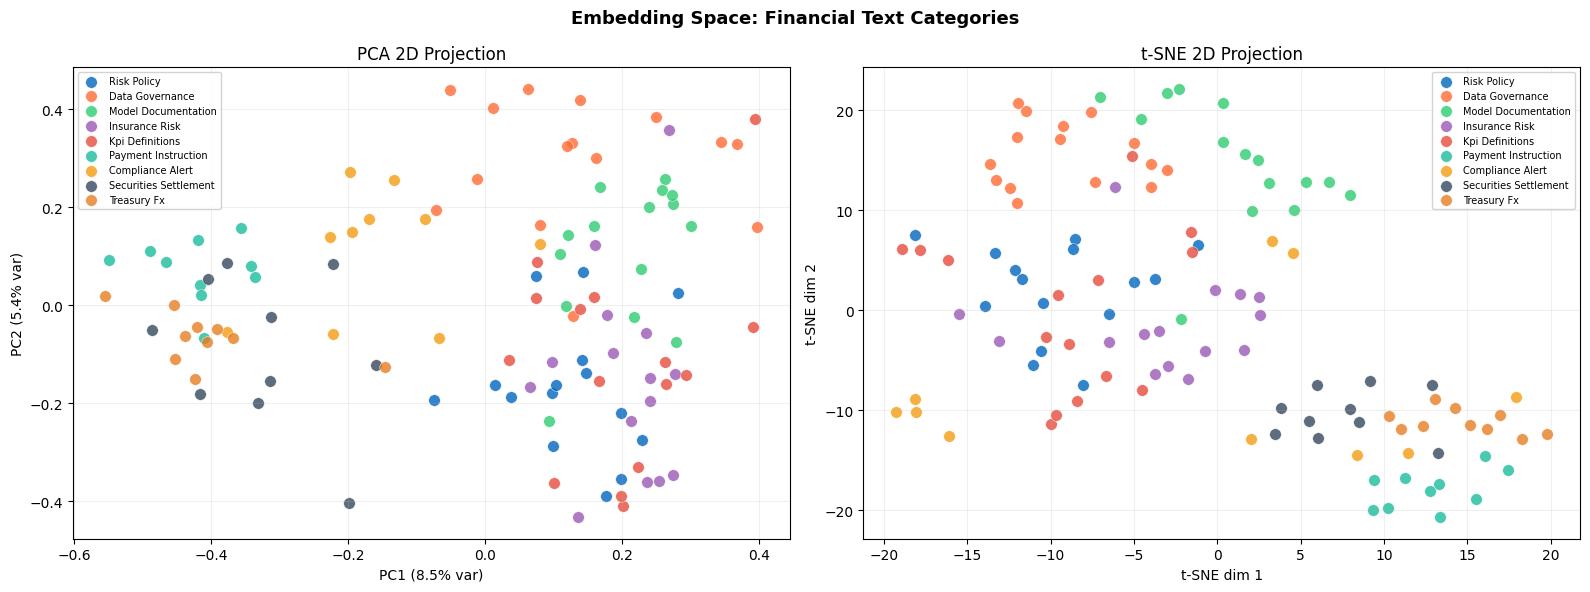

✅ Embedding space visualised
   Well-separated clusters confirm embeddings capture domain distinctions


In [54]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Encode full dataset
X_all_emb = embedder.encode(X.tolist(), normalize_embeddings=True, show_progress_bar=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Embedding Space: Financial Text Categories',
             fontsize=13, fontweight='bold')

# PCA
pca = PCA(n_components=2, random_state=config.random_state)
coords_pca = pca.fit_transform(X_all_emb)
var_explained = pca.explained_variance_ratio_

# t-SNE
tsne = TSNE(n_components=2, random_state=config.random_state, perplexity=15, max_iter=1000)
coords_tsne = tsne.fit_transform(X_all_emb)

for ax, coords, title, xlabel, ylabel in [
    (axes[0], coords_pca, 'PCA 2D Projection',
     f'PC1 ({var_explained[0]*100:.1f}% var)', f'PC2 ({var_explained[1]*100:.1f}% var)'),
    (axes[1], coords_tsne, 't-SNE 2D Projection', 't-SNE dim 1', 't-SNE dim 2'),
]:
    for label in df['label'].unique():
        mask = df['label'].values == label
        ax.scatter(
            coords[mask, 0], coords[mask, 1],
            c=palette.get(label, '#888888'),
            label=label.replace('_', ' ').title(),
            s=70, alpha=0.8, edgecolors='white', linewidths=0.4
        )
    ax.set_title(title, fontsize=12)
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.legend(fontsize=7, loc='best', framealpha=0.85)
    ax.grid(alpha=0.2)

plt.tight_layout()
# plt.savefig(os.path.join(OUTPUT_DIR, 'nb06_embedding_space.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Embedding space visualised")
print("   Well-separated clusters confirm embeddings capture domain distinctions")

## 7. Inference — Classify New Financial Text

In [55]:
def classify_text(text: str, pipeline_model, approach: str = 'tfidf') -> Dict:
    """
    Classify a new financial text using either TF-IDF pipeline
    or embedding-based classifier.

    Args:
        text:           Input financial text
        pipeline_model: Fitted sklearn pipeline or (embedder, clf) tuple
        approach:       'tfidf' or 'embedding'

    Returns:
        Dict with predicted label and confidence scores
    """
    if approach == 'tfidf':
        pred = pipeline_model.predict([text])[0]
        proba = pipeline_model.predict_proba([text])[0]
        classes = pipeline_model.named_steps['clf'].classes_
    else:
        emb_model, clf = pipeline_model
        vec = emb_model.encode([text], normalize_embeddings=True)
        pred = clf.predict(vec)[0]
        proba = clf.predict_proba(vec)[0] if hasattr(clf, 'predict_proba') else None
        classes = clf.classes_

    result = {'predicted_label': pred, 'approach': approach}
    if proba is not None:
        result['confidence'] = dict(sorted(
            zip(classes, proba), key=lambda x: x[1], reverse=True
        ))
        result['top_confidence'] = max(proba)
    return result


# Best embedding classifier for inference
best_emb_clf = emb_results[best_emb_name]['clf']

# Test on unseen financial texts
TEST_CASES = [
    "Urgent wire transfer of EUR 2500000 to correspondent bank in London, same-day value required.",
    "Customer flagged by transaction monitoring: 20 international transfers in 48 hours, AML escalation required.",
    "Settlement of 50000 shares Apple Inc at USD 195.50 via DTC, DVP instruction T+2.",
    "EUR/USD FX swap: buy spot sell forward EUR 10000000, swap points -45, maturity 3 months.",
    "Data quality gate triggered: completeness score dropped to 74, pipeline blocked pending investigation.",
    "The NPL ratio exceeded the 4.5% red threshold requiring immediate Risk Committee notification.",
    "PD model Gini coefficient is 38%, below the 40% amber threshold, model review initiated.",
    "Chain-ladder reserves recalculated for workers compensation line showing adverse development of 8%.",
]

print("🔍 Inference on Unseen Financial Texts")
print("=" * 70)

for text in TEST_CASES:
    r_tfidf = classify_text(text, tfidf_pipeline, approach='tfidf')
    r_emb   = classify_text(text, (embedder, best_emb_clf), approach='embedding')

    agree = '✅' if r_tfidf['predicted_label'] == r_emb['predicted_label'] else '⚠️'
    print(f"\n{agree} Text: {text[:70]}...")
    print(f"   TF-IDF prediction:     {r_tfidf['predicted_label']:<25} (conf: {r_tfidf.get('top_confidence', 0):.2f})")
    print(f"   Embedding prediction:  {r_emb['predicted_label']:<25}")

🔍 Inference on Unseen Financial Texts

✅ Text: Urgent wire transfer of EUR 2500000 to correspondent bank in London, s...
   TF-IDF prediction:     payment_instruction       (conf: 0.16)
   Embedding prediction:  payment_instruction      

⚠️ Text: Customer flagged by transaction monitoring: 20 international transfers...
   TF-IDF prediction:     data_governance           (conf: 0.14)
   Embedding prediction:  compliance_alert         

✅ Text: Settlement of 50000 shares Apple Inc at USD 195.50 via DTC, DVP instru...
   TF-IDF prediction:     securities_settlement     (conf: 0.15)
   Embedding prediction:  securities_settlement    

✅ Text: EUR/USD FX swap: buy spot sell forward EUR 10000000, swap points -45, ...
   TF-IDF prediction:     treasury_fx               (conf: 0.18)
   Embedding prediction:  treasury_fx              

✅ Text: Data quality gate triggered: completeness score dropped to 74, pipelin...
   TF-IDF prediction:     data_governance           (conf: 0.23)
   Embedding 

## 8. Misclassification Analysis

Understanding *why* the model makes mistakes is as important as the accuracy score — especially in regulated financial environments.

In [56]:
# Analyse misclassifications from the best embedding model
best_preds = emb_results[best_emb_name]['preds']
misclassified_mask = best_preds != y_test

df_errors = pd.DataFrame({
    'text':      X_test[misclassified_mask],
    'true':      y_test[misclassified_mask],
    'predicted': best_preds[misclassified_mask]
})

print(f"📋 Misclassification Analysis — {best_emb_name}")
print(f"   Total misclassified: {len(df_errors)} / {len(y_test)} ({len(df_errors)/len(y_test)*100:.1f}%)")

if len(df_errors) > 0:
    print(f"\n   Error pattern (true → predicted):")
    error_pairs = df_errors.groupby(['true', 'predicted']).size().reset_index(name='count')
    error_pairs = error_pairs.sort_values('count', ascending=False)
    print(error_pairs.to_string(index=False))

    print(f"\n   Example misclassifications:")
    for _, row in df_errors.head(3).iterrows():
        print(f"\n   True:      {row['true']}")
        print(f"   Predicted: {row['predicted']}")
        print(f"   Text:      {row['text'][:100]}...")

    print(f"\n   💡 Insight: Misclassifications often occur between semantically")
    print(f"      adjacent categories (e.g. risk_policy ↔ kpi_definitions)")
    print(f"      — both discuss thresholds and limits in financial language.")
    print(f"      More training data or domain fine-tuning would reduce this.")
else:
    print("   🎯 Perfect classification on test set!")

📋 Misclassification Analysis — Linear SVM
   Total misclassified: 7 / 23 (30.4%)

   Error pattern (true → predicted):
                 true       predicted  count
          risk_policy kpi_definitions      2
      data_governance kpi_definitions      1
       insurance_risk kpi_definitions      1
      kpi_definitions  insurance_risk      1
      kpi_definitions     risk_policy      1
securities_settlement     treasury_fx      1

   Example misclassifications:

   True:      kpi_definitions
   Predicted: risk_policy
   Text:      Stage migration rate measures the percentage of Stage 1 portfolio migrating to Stage 2 within a repo...

   True:      risk_policy
   Predicted: kpi_definitions
   Text:      Forbearance measures are applied when a borrower faces financial difficulty and the lender grants co...

   True:      kpi_definitions
   Predicted: insurance_risk
   Text:      Return on risk-adjusted capital measures profitability relative to economic capital consumption by b...

   💡 

## 9. Production Readiness Checklist

In [58]:
print("\n" + "="*70)
print("TEXT CLASSIFICATION: BUILD SUMMARY")
print("="*70)

print("""
PIPELINE COMPONENTS
  ✅ Dataset               : Financial documents + SWIFT-style messages
  ✅ TF-IDF baseline       : Logistic Regression, bigrams, log-normalised
  ✅ Embedding approach    : all-MiniLM-L6-v2 (reused from NB07 RAG)
  ✅ Multi-classifier eval : Logistic Regression, Linear SVM, Random Forest
  ✅ Cross-validation      : Stratified 5-fold F1-macro
  ✅ Feature importance    : Top TF-IDF terms per class (interpretable)
  ✅ Embedding space viz   : PCA + t-SNE cluster analysis
  ✅ Misclassification     : Error pattern analysis with examples
  ✅ Inference function    : classify_text() for production use
""")

print("PERFORMANCE")
print(f"  TF-IDF F1-macro:         {tfidf_f1:.3f}")
print(f"  Best embedding F1-macro: {emb_results[best_emb_name]['test_f1']:.3f} ({best_emb_name})")
print(f"  Number of classes:       {df['label'].nunique()}")
print(f"  Training samples:        {len(X_train)}")

print("""
PROJECT RELEVANCE
  → Message type routing (payment / compliance / securities / FX)
  → Anomalous message flagging for compliance review
  → Document categorisation for knowledge management
  → Regulatory document classification (Basel III, IFRS 9, EMIR)

PRODUCTION CHECKLIST
  ✅ Stratified train-test split (class balance preserved)
  ✅ Cross-validation (generalisation verified)
  ✅ Multiple classifiers compared (not just one model)
  ✅ Interpretability: TF-IDF feature importance available
  ✅ Misclassification analysis (know where model fails)
  ✅ Config-driven (ClassifierConfig dataclass)
  ✅ Reusable inference function
  ⬜ Fine-tune on actual MT/MX message corpus
  ⬜ Domain-adapted transformer (FinBERT) for higher accuracy
  ⬜ Active learning loop for low-confidence predictions
  ⬜ FastAPI endpoint + Docker container for deployment

NEXT STEPS
  → FinBERT fine-tuning on financial text corpus
  → Named Entity Recognition for financial message parsing
  → Integration with NB07 RAG: classify query → route to specialised index
""")
print("="*70)
print("Portfolio: github.com/nicherina/retail-demand-intelligence")
print("Author:    Nisrina Afnan Walyadin | MSc Mathematics, TU Munich")
print("="*70)


TEXT CLASSIFICATION: BUILD SUMMARY

PIPELINE COMPONENTS
  ✅ Dataset               : Financial documents + SWIFT-style messages
  ✅ TF-IDF baseline       : Logistic Regression, bigrams, log-normalised
  ✅ Embedding approach    : all-MiniLM-L6-v2 (reused from NB07 RAG)
  ✅ Multi-classifier eval : Logistic Regression, Linear SVM, Random Forest
  ✅ Cross-validation      : Stratified 5-fold F1-macro
  ✅ Feature importance    : Top TF-IDF terms per class (interpretable)
  ✅ Embedding space viz   : PCA + t-SNE cluster analysis
  ✅ Misclassification     : Error pattern analysis with examples
  ✅ Inference function    : classify_text() for production use

PERFORMANCE
  TF-IDF F1-macro:         0.577
  Best embedding F1-macro: 0.731 (Linear SVM)
  Number of classes:       9
  Training samples:        92

PROJECT RELEVANCE
  → Message type routing (payment / compliance / securities / FX)
  → Anomalous message flagging for compliance review
  → Document categorisation for knowledge management
  →